# VIP Customer Value Churn — Improved Pipeline
### Systematic improvements: cleaned structure · new features · proper visualizations · tuned models

**Run order: top to bottom, one cell at a time. Never skip a cell.**

| Step | Cell | What it does |
|------|------|--------------|
| 1 | Imports | All libraries once, upfront |
| 2 | Load & Clean | Dask pipeline, outlier cap |
| 3 | Time Slicing | Safe window detection |
| 4 | Feature Engineering | All features in one Dask batch |
| 5 | VIZ — EDA | Spend distributions, class balance |
| 6 | GMM Clustering | Find true VIPs |
| 7 | VIZ — Clusters | Scatter plot of clusters |
| 8 | Target Redefinition | 70% value-churn rule |
| 9 | VIZ — Target | Class balance + feature correlations |
| 10 | Train/Test Split | Stratified 75/25 |
| 11 | Model 1: LR | GridSearchCV, churn-optimised scorer |
| 12 | Model 2: XGBoost | RandomizedSearchCV, tuned |
| 13 | VIZ — Results | Threshold calibration + feature importance |
| 14 | Final Model | Best model, final report, export |

In [1]:
# ============================================================
# CELL 1 — ALL IMPORTS (run this first, always)
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import dask
import dask.dataframe as dd
import datetime
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    make_scorer, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# Plotting style — clean and readable
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# ============================================================
# CELL 2 — LOAD, MERGE & CLEAN  (memory-safe Dask pipeline)
# ============================================================
print('STEP 1: Loading parquet files...')
df_main = dd.read_parquet('transactions_parquet/')
df_time  = dd.read_parquet('time_parquet/')

print('STEP 2: Merging on SHOP_WEEK...')
df_time = df_time.rename(columns={'shop_week': 'SHOP_WEEK'})
df = dd.merge(df_main, df_time, on='SHOP_WEEK', how='left')

print('STEP 3: Basic cleaning — drop nulls & returns...')
critical_cols = ['CUST_CODE', 'SPEND', 'QUANTITY', 'SHOP_DATE']
df_clean = df.dropna(subset=critical_cols)
df_clean = df_clean[(df_clean['QUANTITY'] > 0) & (df_clean['SPEND'] > 0)]

print('STEP 4: Parsing dates...')
df_clean['Transaction_Date'] = dd.to_datetime(
    df_clean['SHOP_DATE'], format='%Y%m%d', errors='coerce'
)
df_clean = df_clean.dropna(subset=['Transaction_Date'])

print('STEP 5: Outlier cap at 99th percentile (removes B2B noise)...')
spend_99, qty_99 = dask.compute(
    df_clean['SPEND'].quantile(0.99),
    df_clean['QUANTITY'].quantile(0.99)
)
print(f'   -> Spend cap: £{spend_99:.2f}  |  Qty cap: {qty_99:.0f} units')
df_final = df_clean[
    (df_clean['SPEND'] <= spend_99) &
    (df_clean['QUANTITY'] <= qty_99)
]

print('STEP 6: Keeping only the 6 columns needed for modelling...')
core_columns = ['CUST_CODE', 'Transaction_Date', 'SPEND', 'QUANTITY', 'PROD_CODE', 'BASKET_ID']
df_model = df_final[core_columns].dropna()

# Count without loading everything into RAM
final_rows = df_model.map_partitions(len).compute().sum()

print('\n' + '='*55)
print('CLEANING COMPLETE')
print('='*55)
print(f'Total valid transactions: {final_rows:,}')
print('='*55)
display(df_model.head(5))

STEP 1: Loading parquet files...
STEP 2: Merging on SHOP_WEEK...
STEP 3: Basic cleaning — drop nulls & returns...
STEP 4: Parsing dates...
STEP 5: Outlier cap at 99th percentile (removes B2B noise)...
   -> Spend cap: £16.29  |  Qty cap: 10 units
STEP 6: Keeping only the 6 columns needed for modelling...

CLEANING COMPLETE
Total valid transactions: 245,976,814


,CUST_CODE,Transaction_Date,SPEND,QUANTITY,PROD_CODE,BASKET_ID
0,CUST0000167145,2006-04-10,1.01,1,PRD0900005,994100100253028
1,CUST0000246027,2006-04-16,3.03,3,PRD0900005,994100100299966
2,CUST0000140993,2006-04-13,0.22,1,PRD0900006,994100100237197
3,CUST0000938246,2006-04-16,0.22,1,PRD0900007,994100100715506
4,CUST0000994485,2006-04-14,1.77,1,PRD0900008,994100100749139


In [3]:
# ============================================================
# CELL 3 — SAFE TIME SLICING  (no data leakage)
# ============================================================
print('STEP 1: Detecting safe holiday window...')
max_date = df_model['Transaction_Date'].max().compute()

# We need a FULL 6-month post-holiday window to track retention.
# Rule: if dataset ends before Jun-30, go back one extra year.
if max_date >= pd.to_datetime(f'{max_date.year}-06-30'):
    target_year = max_date.year - 1
else:
    target_year = max_date.year - 2

holiday_start = pd.to_datetime(f'{target_year}-11-01')
holiday_end   = pd.to_datetime(f'{target_year}-12-31')
post_start    = pd.to_datetime(f'{target_year + 1}-01-01')
post_end      = pd.to_datetime(f'{target_year + 1}-06-30')
# Pre-holiday = everything before Nov 1 of target year

print(f'   Dataset ends       : {max_date.date()}')
print(f'   Pre-holiday        : before {holiday_start.date()}')
print(f'   Holiday peak       : {holiday_start.date()} to {holiday_end.date()}')
print(f'   Post-holiday track : {post_start.date()} to {post_end.date()}')

print('\nSTEP 2: Slicing Dask dataframes (lazy, no RAM spike)...')
holiday_df     = df_model[
    (df_model['Transaction_Date'] >= holiday_start) &
    (df_model['Transaction_Date'] <= holiday_end)
]
post_holiday_df = df_model[
    (df_model['Transaction_Date'] >= post_start) &
    (df_model['Transaction_Date'] <= post_end)
]
pre_holiday_df  = df_model[df_model['Transaction_Date'] < holiday_start]

print('Time windows defined. Ready for feature engineering.')

STEP 1: Detecting safe holiday window...
   Dataset ends       : 2008-07-06
   Pre-holiday        : before 2007-11-01
   Holiday peak       : 2007-11-01 to 2007-12-31
   Post-holiday track : 2008-01-01 to 2008-06-30

STEP 2: Slicing Dask dataframes (lazy, no RAM spike)...
Time windows defined. Ready for feature engineering.


In [4]:
# ============================================================
# CELL 4 — FEATURE ENGINEERING  (all features, single Dask batch)
#
# NEW vs ORIGINAL:
#   + Pre_Recency         — days since last pre-holiday shop
#   + Holiday_Uplift_Ratio — how much did spend spike vs normal?
#   + Avg_Basket_Size      — spend-per-visit signal
#   + Holiday_Spend_Velocity (fixed) — log-ratio avoids infinity
#   Pre_Frequency & Pre_Monetary kept from original
# ============================================================
print('Computing HOLIDAY features...')
h_group = holiday_df.groupby('CUST_CODE')

h_last_date   = h_group['Transaction_Date'].max()
h_freq        = h_group['BASKET_ID'].nunique()
h_monetary    = h_group['SPEND'].sum()
h_unique_prods= h_group['PROD_CODE'].nunique()
h_qty         = h_group['QUANTITY'].sum()

# Nov & Dec spend for velocity feature — computed together to save scans
nov_df = holiday_df[holiday_df['Transaction_Date'].dt.month == 11]
dec_df = holiday_df[holiday_df['Transaction_Date'].dt.month == 12]
h_nov_spend = nov_df.groupby('CUST_CODE')['SPEND'].sum()
h_dec_spend = dec_df.groupby('CUST_CODE')['SPEND'].sum()

print('Computing PRE-HOLIDAY features...')
pre_group     = pre_holiday_df.groupby('CUST_CODE')
pre_freq      = pre_group['BASKET_ID'].nunique()
pre_monetary  = pre_group['SPEND'].sum()
pre_last_date = pre_group['Transaction_Date'].max()    # NEW

print('Computing POST-HOLIDAY data for target variable...')
# Only need the unique list — cheap compute
post_unique = post_holiday_df['CUST_CODE'].unique()

print('\nExecuting single parallel Dask compute (most memory-efficient method)...')
(
    h_last_date, h_freq, h_monetary, h_unique_prods, h_qty,
    h_nov_spend, h_dec_spend,
    pre_freq, pre_monetary, pre_last_date,
    retained_customers
) = dask.compute(
    h_last_date, h_freq, h_monetary, h_unique_prods, h_qty,
    h_nov_spend, h_dec_spend,
    pre_freq, pre_monetary, pre_last_date,
    post_unique
)

print('\nAssembling HOLIDAY feature table...')
holiday_features = pd.concat([
    h_last_date.rename('Last_Purchase_Date'),
    h_freq.rename('Holiday_Frequency'),
    h_monetary.rename('Holiday_Monetary'),
    h_unique_prods.rename('Holiday_UniqueProducts'),
    h_qty.rename('Holiday_TotalItems'),
    h_nov_spend.rename('Nov_Spend'),
    h_dec_spend.rename('Dec_Spend'),
], axis=1).reset_index()

holiday_features['Last_Purchase_Date'] = pd.to_datetime(
    holiday_features['Last_Purchase_Date'], errors='coerce'
)
holiday_features = holiday_features.dropna(subset=['Last_Purchase_Date'])

# --- Derive holiday features ---
holiday_features['Holiday_Recency'] = (
    holiday_end - holiday_features['Last_Purchase_Date']
).dt.days

holiday_features['Holiday_ProductDiversity'] = (
    holiday_features['Holiday_UniqueProducts'] /
    holiday_features['Holiday_TotalItems'].clip(lower=1)
)

# NEW: average spend per basket visit
holiday_features['Avg_Basket_Size'] = (
    holiday_features['Holiday_Monetary'] /
    holiday_features['Holiday_Frequency'].clip(lower=1)
)

# NEW: spend velocity as log-ratio — avoids infinity when Nov_Spend is 0
holiday_features['Holiday_Spend_Velocity'] = (
    np.log1p(holiday_features['Dec_Spend']) -
    np.log1p(holiday_features['Nov_Spend'].fillna(0))
)

print('\nAssembling PRE-HOLIDAY feature table...')
pre_features = pd.concat([
    pre_freq.rename('Pre_Frequency'),
    pre_monetary.rename('Pre_Monetary'),
    pre_last_date.rename('Pre_LastDate'),     # NEW
], axis=1).reset_index()

pre_features['Pre_LastDate'] = pd.to_datetime(
    pre_features['Pre_LastDate'], errors='coerce'
)

# NEW: Pre_Recency — how recently did they shop BEFORE the holiday season?
pre_features['Pre_Recency'] = (
    holiday_start - pre_features['Pre_LastDate']
).dt.days.clip(lower=0)
pre_features.drop(columns=['Pre_LastDate'], inplace=True)

print('\nMerging into final ML dataset...')
ml_data = holiday_features.merge(pre_features, on='CUST_CODE', how='left')
ml_data = ml_data.fillna(0)

# Soft target (any post-holiday appearance) — will be overridden by value-churn rule
ml_data['Retained'] = ml_data['CUST_CODE'].isin(retained_customers).astype(int)

# Drop raw helper columns before setting index
drop_cols = ['Last_Purchase_Date', 'Holiday_UniqueProducts',
             'Holiday_TotalItems', 'Nov_Spend', 'Dec_Spend']
ml_data.drop(columns=drop_cols, inplace=True)
ml_data.set_index('CUST_CODE', inplace=True)

print('\n' + '='*55)
print('FEATURE ENGINEERING COMPLETE')
print('='*55)
print(f'Total holiday shoppers : {len(ml_data):,}')
print(f'Features created       : {len(ml_data.columns) - 1}')
print(f'Feature list: {[c for c in ml_data.columns if c != "Retained"]}')
print('='*55)
display(ml_data.head())

Computing HOLIDAY features...
Computing PRE-HOLIDAY features...
Computing POST-HOLIDAY data for target variable...

Executing single parallel Dask compute (most memory-efficient method)...

Assembling HOLIDAY feature table...

Assembling PRE-HOLIDAY feature table...

Merging into final ML dataset...

FEATURE ENGINEERING COMPLETE
Total holiday shoppers : 309,415
Features created       : 9
Feature list: ['Holiday_Frequency', 'Holiday_Monetary', 'Holiday_Recency', 'Holiday_ProductDiversity', 'Avg_Basket_Size', 'Holiday_Spend_Velocity', 'Pre_Frequency', 'Pre_Monetary', 'Pre_Recency']


,Holiday_Frequency,Holiday_Monetary,Holiday_Recency,Holiday_ProductDiversity,Avg_Basket_Size,Holiday_Spend_Velocity,Pre_Frequency,Pre_Monetary,Pre_Recency,Retained
CUST_CODE,,,,,,,,,,
CUST0000000327,29,196.01,0,0.408163,6.758966,0.398610,252.0,1148.77,1.0,1
CUST0000001173,22,129.84,3,0.543046,5.901818,-0.282198,312.0,2221.38,1.0,1
CUST0000001247,13,35.63,2,0.642857,2.740769,-0.114395,150.0,1070.39,10.0,1
CUST0000001981,6,20.52,33,0.473684,3.420000,0.000000,54.0,110.70,88.0,1
CUST0000002098,3,96.54,12,0.596774,32.180000,0.291057,18.0,835.41,24.0,1


Building EDA visualisations (sampling 5,000 rows)...


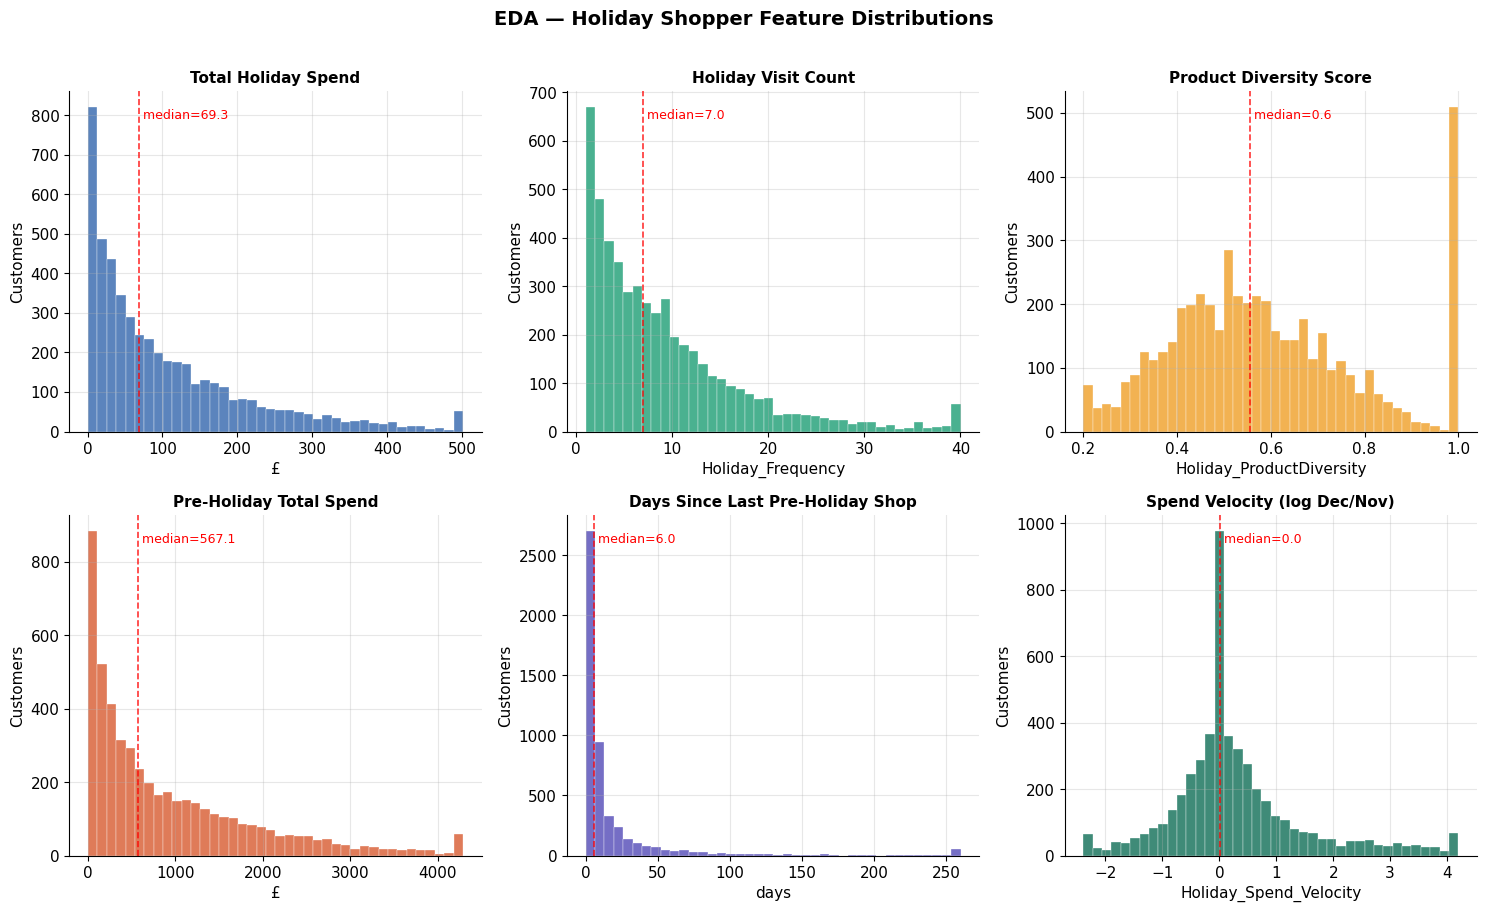

Saved: viz_01_eda_distributions.png


In [5]:
# ============================================================
# CELL 5 — VISUALISATION 1: EDA — Spend & Feature Distributions
# (run on a sample to keep it fast and memory-safe)
# ============================================================
print('Building EDA visualisations (sampling 5,000 rows)...')
sample = ml_data.sample(n=min(5000, len(ml_data)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('EDA — Holiday Shopper Feature Distributions', fontsize=14, fontweight='bold', y=1.01)

features_to_plot = [
    ('Holiday_Monetary',        '£',  'Total Holiday Spend'),
    ('Holiday_Frequency',       '',   'Holiday Visit Count'),
    ('Holiday_ProductDiversity','',   'Product Diversity Score'),
    ('Pre_Monetary',            '£',  'Pre-Holiday Total Spend'),
    ('Pre_Recency',             'days','Days Since Last Pre-Holiday Shop'),
    ('Holiday_Spend_Velocity',  '',   'Spend Velocity (log Dec/Nov)'),
]

colors = ['#3266ad', '#1D9E75', '#EF9F27', '#D85A30', '#534AB7', '#0F6E56']

for ax, (col, unit, title), color in zip(axes.flat, features_to_plot, colors):
    data = sample[col].clip(
        lower=sample[col].quantile(0.01),
        upper=sample[col].quantile(0.99)
    )
    ax.hist(data, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(unit if unit else col)
    ax.set_ylabel('Customers')
    median_val = data.median()
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.text(median_val, ax.get_ylim()[1] * 0.92,
            f' median={median_val:.1f}', color='red', fontsize=9)

plt.tight_layout()
plt.savefig('viz_01_eda_distributions.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_01_eda_distributions.png')

In [6]:
# ============================================================
# CELL 6 — GMM CLUSTERING: Find True VIPs
# ============================================================
print('STEP 1: Preparing clustering data...')
cluster_features = ['Holiday_Recency', 'Holiday_Frequency', 'Holiday_Monetary']
X_cluster = ml_data[cluster_features]

print('STEP 2: Scaling (mandatory for GMM distance math)...')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print('STEP 3: Fitting GMM with 3 components...')
gmm = GaussianMixture(n_components=3, random_state=42, covariance_type='full')
ml_data['Cluster'] = gmm.fit_predict(X_scaled)

print('STEP 4: Identifying VIP cluster (highest avg monetary)...')
cluster_summary = ml_data.groupby('Cluster')[
    ['Holiday_Monetary', 'Holiday_Frequency', 'Holiday_Recency']
].mean()

vip_cluster_id = cluster_summary['Holiday_Monetary'].idxmax()
vip_data       = ml_data[ml_data['Cluster'] == vip_cluster_id].copy()

print('\n' + '='*55)
print('GMM CLUSTERING COMPLETE')
print('='*55)
print('Cluster averages:')
print(cluster_summary.round(2))
print('-'*55)
print(f'VIP cluster ID     : {vip_cluster_id}')
print(f'True VIPs found    : {len(vip_data):,}')
print(f'VIP % of shoppers  : {len(vip_data)/len(ml_data)*100:.1f}%')
print('='*55)

STEP 1: Preparing clustering data...
STEP 2: Scaling (mandatory for GMM distance math)...
STEP 3: Fitting GMM with 3 components...
STEP 4: Identifying VIP cluster (highest avg monetary)...

GMM CLUSTERING COMPLETE
Cluster averages:
         Holiday_Monetary  Holiday_Frequency  Holiday_Recency
Cluster                                                      
0                   89.58               7.72             8.58
1                  247.04              19.46             3.06
2                   17.84               2.07            24.16
-------------------------------------------------------
VIP cluster ID     : 1
True VIPs found    : 80,908
VIP % of shoppers  : 26.1%


Building GMM cluster visualisation...


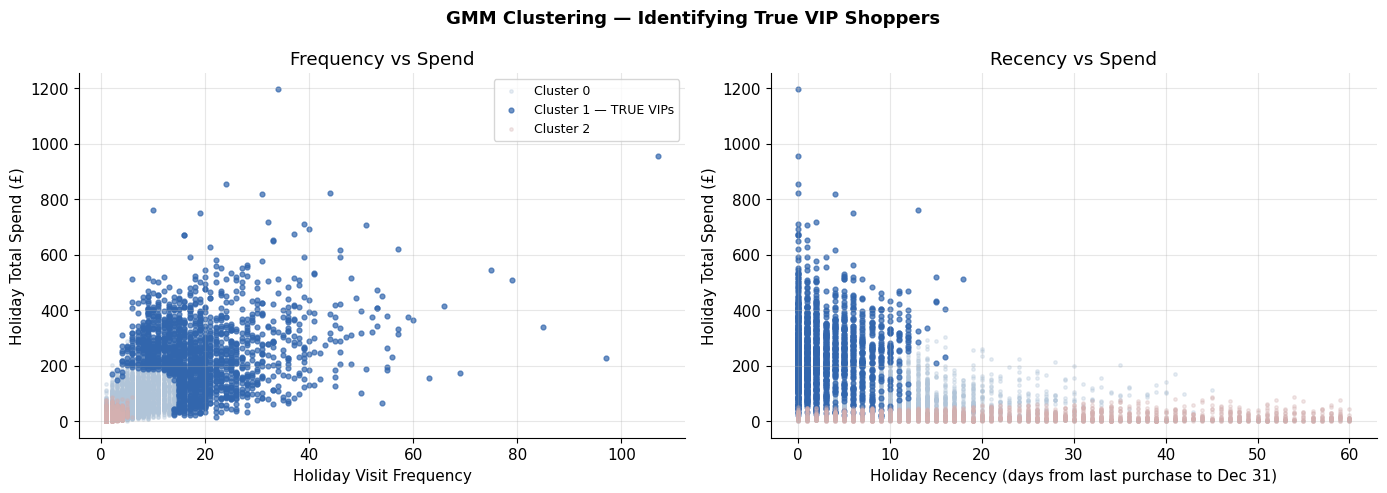

Saved: viz_02_gmm_clusters.png


In [7]:
# ============================================================
# CELL 7 — VISUALISATION 2: GMM Cluster Scatter
# ============================================================
print('Building GMM cluster visualisation...')
sample_cluster = ml_data.sample(n=min(6000, len(ml_data)), random_state=42)

cluster_palette = {0: '#B0C4D8', 1: '#B0D4C0', 2: '#D4B0B0'}
vip_color = '#3266ad'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GMM Clustering — Identifying True VIP Shoppers', fontsize=13, fontweight='bold')

# --- Plot 1: Frequency vs Monetary ---
for c in sorted(sample_cluster['Cluster'].unique()):
    sub  = sample_cluster[sample_cluster['Cluster'] == c]
    clr  = vip_color if c == vip_cluster_id else cluster_palette[c]
    lbl  = f'Cluster {c} — TRUE VIPs' if c == vip_cluster_id else f'Cluster {c}'
    alp  = 0.7 if c == vip_cluster_id else 0.3
    size = 12  if c == vip_cluster_id else 6
    ax1.scatter(sub['Holiday_Frequency'], sub['Holiday_Monetary'],
                c=clr, alpha=alp, s=size, label=lbl)

ax1.set_xlabel('Holiday Visit Frequency')
ax1.set_ylabel('Holiday Total Spend (£)')
ax1.set_title('Frequency vs Spend')
ax1.legend(fontsize=9)

# --- Plot 2: Recency vs Monetary ---
for c in sorted(sample_cluster['Cluster'].unique()):
    sub  = sample_cluster[sample_cluster['Cluster'] == c]
    clr  = vip_color if c == vip_cluster_id else cluster_palette[c]
    alp  = 0.7 if c == vip_cluster_id else 0.3
    size = 12  if c == vip_cluster_id else 6
    ax2.scatter(sub['Holiday_Recency'], sub['Holiday_Monetary'],
                c=clr, alpha=alp, s=size)

ax2.set_xlabel('Holiday Recency (days from last purchase to Dec 31)')
ax2.set_ylabel('Holiday Total Spend (£)')
ax2.set_title('Recency vs Spend')

plt.tight_layout()
plt.savefig('viz_02_gmm_clusters.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_02_gmm_clusters.png')

In [8]:
# ============================================================
# CELL 8 — TARGET REDEFINITION: Value Churn (70% Rule)
#
# All post-holiday spend is fetched here in one go and kept
# as a column so we never lose it between cells.
# ============================================================
print('STEP 1: Fetching post-holiday spend for VIPs only (Dask compute)...')
vip_list = vip_data.index.tolist()

post_vip_df = post_holiday_df[post_holiday_df['CUST_CODE'].isin(vip_list)]
post_spend  = post_vip_df.groupby('CUST_CODE')['SPEND'].sum().compute()

vip_data['Post_Holiday_Spend']      = vip_data.index.map(post_spend).fillna(0)
vip_data['Holiday_Monthly_RunRate'] = vip_data['Holiday_Monetary'] / 2   # 2-month holiday
vip_data['Post_Monthly_RunRate']    = vip_data['Post_Holiday_Spend'] / 6  # 6-month tracking

print('STEP 2: Applying 70% Maintenance Rule...')
# A VIP "retained" their status only if they maintained ≥70% of holiday monthly spend
vip_data['Retained'] = (
    vip_data['Post_Monthly_RunRate'] >= vip_data['Holiday_Monthly_RunRate'] * 0.70
).astype(int)

print('STEP 3: Engineering Holiday Uplift Ratio (new feature)...')
# How much MORE does this VIP spend in holidays vs their normal pre-holiday monthly rate?
# High uplift = holiday-only shopper; Low uplift = consistent year-round VIP
pre_monthly_avg = vip_data['Pre_Monetary'] / 12
vip_data['Holiday_Uplift_Ratio'] = (
    vip_data['Holiday_Monthly_RunRate'] / pre_monthly_avg.clip(lower=1)
).clip(upper=20)  # cap extreme outliers

# Clean up calculation helpers (keep data lean)
vip_data.drop(
    columns=['Post_Holiday_Spend', 'Holiday_Monthly_RunRate', 'Post_Monthly_RunRate'],
    inplace=True
)

n_retained   = vip_data['Retained'].sum()
n_downgraded = len(vip_data) - n_retained

print('\n' + '='*55)
print("TARGET VARIABLE: 'VALUE CHURN' (70% Rule)")
print('='*55)
print(f'Retained VIP status (1) : {n_retained:,}  ({n_retained/len(vip_data)*100:.1f}%)')
print(f'Downgraded / Churned (0): {n_downgraded:,}  ({n_downgraded/len(vip_data)*100:.1f}%)')
print('='*55)
display(vip_data.head())

STEP 1: Fetching post-holiday spend for VIPs only (Dask compute)...
STEP 2: Applying 70% Maintenance Rule...
STEP 3: Engineering Holiday Uplift Ratio (new feature)...

TARGET VARIABLE: 'VALUE CHURN' (70% Rule)
Retained VIP status (1) : 60,259  (74.5%)
Downgraded / Churned (0): 20,649  (25.5%)


,Holiday_Frequency,Holiday_Monetary,Holiday_Recency,Holiday_ProductDiversity,Avg_Basket_Size,Holiday_Spend_Velocity,Pre_Frequency,Pre_Monetary,Pre_Recency,Retained,Cluster,Holiday_Uplift_Ratio
CUST_CODE,,,,,,,,,,,,
CUST0000000327,29,196.01,0,0.408163,6.758966,0.398610,252.0,1148.77,1.0,0,1,1.023756
CUST0000001173,22,129.84,3,0.543046,5.901818,-0.282198,312.0,2221.38,1.0,1,1,0.350701
CUST0000007796,18,66.82,1,0.820513,3.712222,-0.421110,158.0,520.29,4.0,1,1,0.770570
CUST0000008102,8,499.49,10,0.264706,62.436250,-0.730290,160.0,4738.36,6.0,1,1,0.632485
CUST0000009151,34,613.80,0,0.239180,18.052941,0.697584,144.0,2886.59,2.0,0,1,1.275831


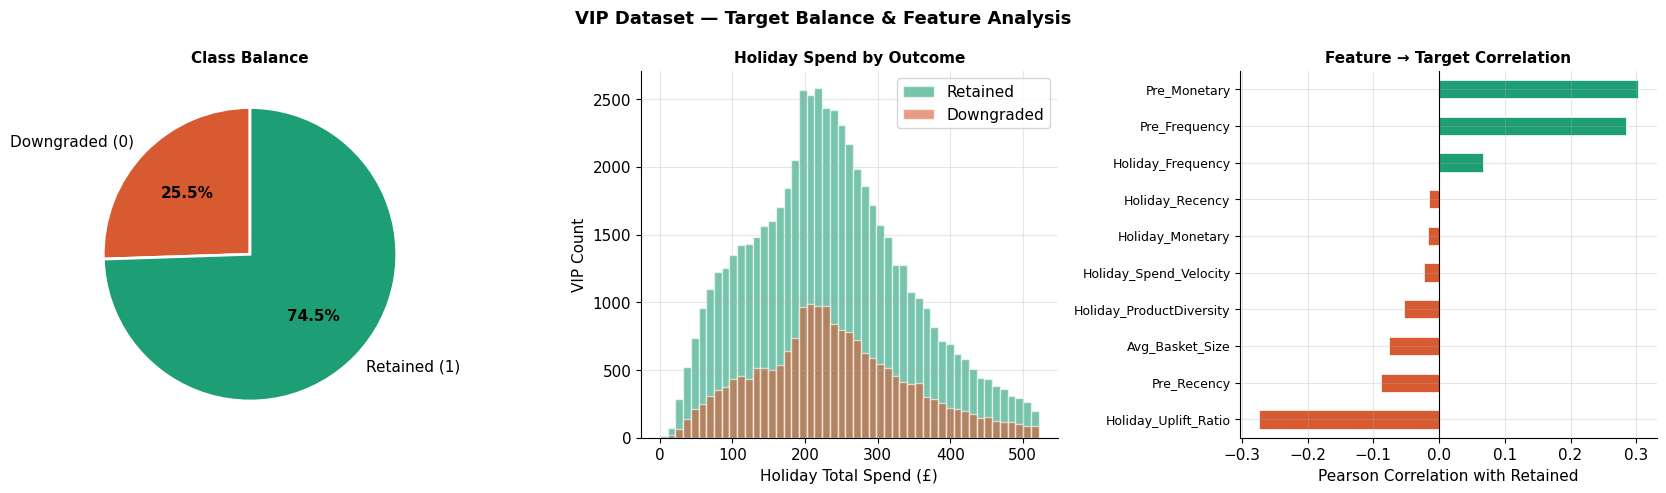

Saved: viz_03_target_and_correlations.png


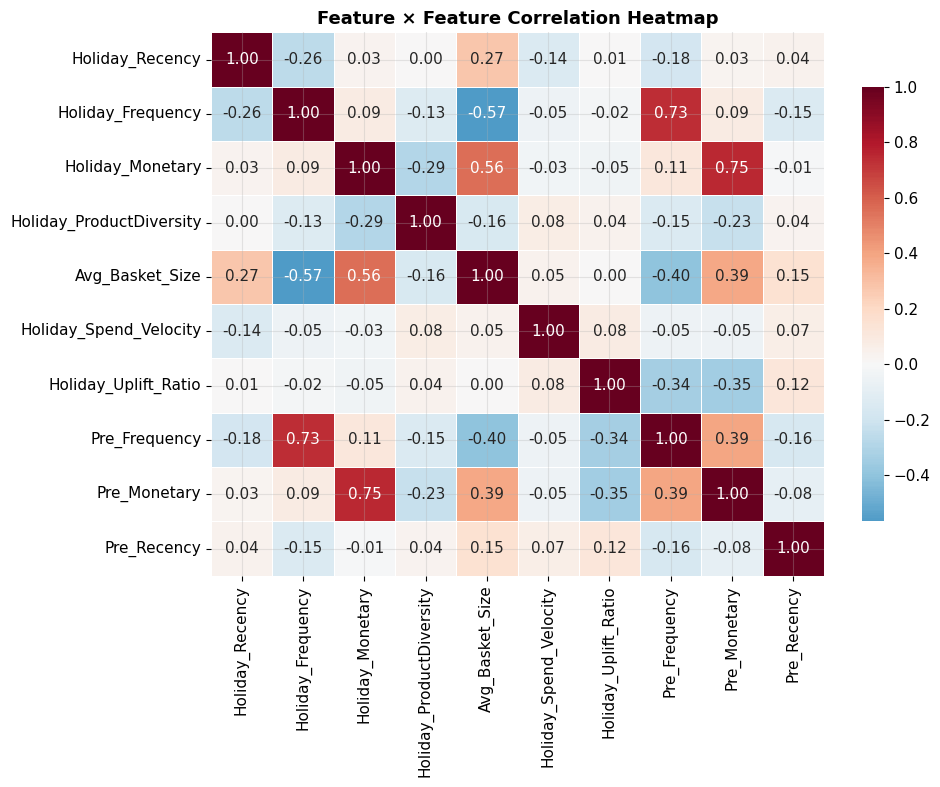

Saved: viz_04_feature_heatmap.png


In [9]:
# ============================================================
# CELL 9 — VISUALISATION 3: Class Balance + Feature Correlations
# ============================================================
ALL_FEATURES = [
    'Holiday_Recency', 'Holiday_Frequency', 'Holiday_Monetary',
    'Holiday_ProductDiversity', 'Avg_Basket_Size', 'Holiday_Spend_Velocity',
    'Holiday_Uplift_Ratio', 'Pre_Frequency', 'Pre_Monetary', 'Pre_Recency'
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('VIP Dataset — Target Balance & Feature Analysis', fontsize=13, fontweight='bold')

# --- Plot 1: Class balance pie ---
ax = axes[0]
counts = vip_data['Retained'].value_counts().sort_index()
labels = ['Downgraded (0)', 'Retained (1)']
colors = ['#D85A30', '#1D9E75']
wedges, texts, autotexts = ax.pie(
    counts, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Class Balance', fontsize=11, fontweight='bold')

# --- Plot 2: Retained vs Downgraded spend distribution ---
ax = axes[1]
retained   = vip_data[vip_data['Retained'] == 1]['Holiday_Monetary']
downgraded = vip_data[vip_data['Retained'] == 0]['Holiday_Monetary']
bins = np.linspace(0, vip_data['Holiday_Monetary'].quantile(0.97), 50)
ax.hist(retained,   bins=bins, alpha=0.6, color='#1D9E75', label='Retained',   edgecolor='white')
ax.hist(downgraded, bins=bins, alpha=0.6, color='#D85A30', label='Downgraded', edgecolor='white')
ax.set_xlabel('Holiday Total Spend (£)')
ax.set_ylabel('VIP Count')
ax.set_title('Holiday Spend by Outcome', fontsize=11, fontweight='bold')
ax.legend()

# --- Plot 3: Feature correlation with target ---
ax = axes[2]
corr_with_target = (
    vip_data[ALL_FEATURES + ['Retained']]
    .corr()['Retained']
    .drop('Retained')
    .sort_values()
)
bar_colors = ['#D85A30' if v < 0 else '#1D9E75' for v in corr_with_target]
corr_with_target.plot(
    kind='barh', ax=ax, color=bar_colors, edgecolor='white', linewidth=0.5
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Retained')
ax.set_title('Feature → Target Correlation', fontsize=11, fontweight='bold')
ax.set_yticklabels(corr_with_target.index, fontsize=9)

plt.tight_layout()
plt.savefig('viz_03_target_and_correlations.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_03_target_and_correlations.png')

# --- Bonus: Correlation heatmap (full feature × feature matrix) ---
fig2, ax2 = plt.subplots(figsize=(10, 8))
corr_matrix = vip_data[ALL_FEATURES].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax2, cbar_kws={'shrink': 0.8}
)
ax2.set_title('Feature × Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_04_feature_heatmap.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_04_feature_heatmap.png')

In [10]:
# ============================================================
# CELL 10 — TRAIN / TEST SPLIT
# ============================================================
print('Defining final feature set...')

# All engineered features
FEATURES = [
    # --- Original features (kept) ---
    'Holiday_Recency',
    'Holiday_Frequency',
    'Holiday_Monetary',
    'Holiday_ProductDiversity',
    'Pre_Frequency',
    'Pre_Monetary',
    # --- New features ---
    'Pre_Recency',           # How recently did they shop before the holidays?
    'Avg_Basket_Size',       # Spend per visit — loyalty signal
    'Holiday_Spend_Velocity',# Log Dec/Nov momentum
    'Holiday_Uplift_Ratio',  # Holiday spike vs normal spend
]

X = vip_data[FEATURES]
y = vip_data['Retained']

print('Splitting 75% train / 25% test (stratified)...')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('\n' + '='*55)
print('DATA SPLIT COMPLETE')
print('='*55)
print(f'Training rows : {X_train.shape[0]:,}')
print(f'Test rows     : {X_test.shape[0]:,}')
print(f'Features      : {X_train.shape[1]}')
print(f'Train balance : {y_train.mean()*100:.1f}% retained')
print(f'Test balance  : {y_test.mean()*100:.1f}% retained')
print('='*55)

Defining final feature set...
Splitting 75% train / 25% test (stratified)...

DATA SPLIT COMPLETE
Training rows : 60,681
Test rows     : 20,227
Features      : 10
Train balance : 74.5% retained
Test balance  : 74.5% retained


In [11]:
# ============================================================
# CELL 11 — MODEL 1: LOGISTIC REGRESSION
#
# FIX 1: Scoring now targets the MINORITY class (churners = 0)
#         not f1_macro — this is what the business actually cares about
# FIX 2: Wider C grid + max_iter=1000 to ensure convergence
# FIX 3: l-bfgs solver included alongside liblinear for L2
# ============================================================
print('Building custom churn scorer (optimise for minority class)...')
# This scorer grades every cross-validation fold on how well it catches
# churners (class 0) — not a macro average. This is the key fix.
churn_f1_scorer = make_scorer(f1_score, pos_label=0)

print('Building LR pipeline...')
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# Wider grid — gives the algorithm real room to explore
lr_param_grid = {
    'lr__penalty': ['l1', 'l2'],
    'lr__C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__solver':  ['liblinear'],   # supports both L1 and L2
}

print('Running GridSearchCV (this tests 12 combos × 5 folds = 60 fits)...')
lr_grid = GridSearchCV(
    lr_pipeline, lr_param_grid,
    cv=5,
    scoring=churn_f1_scorer,  # <- optimise for catching churners
    n_jobs=-1,
    verbose=0
)
lr_grid.fit(X_train, y_train)

best_lr    = lr_grid.best_estimator_
y_pred_lr  = best_lr.predict(X_test)

print('\n' + '='*55)
print('LOGISTIC REGRESSION RESULTS')
print('='*55)
print(f'Best params   : {lr_grid.best_params_}')
print(f'CV F1 (churn) : {lr_grid.best_score_:.4f}')
print('-'*55)
print('Classification Report:')
print(classification_report(y_test, y_pred_lr,
      target_names=['Downgraded (0)', 'Retained (1)']))
print('='*55)

Building custom churn scorer (optimise for minority class)...
Building LR pipeline...
Running GridSearchCV (this tests 12 combos × 5 folds = 60 fits)...

LOGISTIC REGRESSION RESULTS
Best params   : {'lr__C': 100, 'lr__penalty': 'l2', 'lr__solver': 'liblinear'}
CV F1 (churn) : 0.6221
-------------------------------------------------------
Classification Report:
                precision    recall  f1-score   support

Downgraded (0)       0.54      0.76      0.63      5162
  Retained (1)       0.90      0.78      0.84     15065

      accuracy                           0.77     20227
     macro avg       0.72      0.77      0.73     20227
  weighted avg       0.81      0.77      0.78     20227



In [12]:
# ============================================================
# CELL 12 — MODEL 2: XGBOOST (properly tuned)
#
# FIX 1: scale_pos_weight replaces sample_weight — it's native
#         to XGBoost and embedded directly into the loss function
# FIX 2: gamma, min_child_weight added — were never tuned before
# FIX 3: Same churn_f1_scorer so comparison is apples-to-apples
# FIX 4: n_jobs=1 on outer search — XGBoost uses all cores itself
# ============================================================
n_neg  = int((y_train == 0).sum())   # downgraded
n_pos  = int((y_train == 1).sum())   # retained
spw    = round(n_pos / n_neg, 2)     # scale_pos_weight = majority / minority
# NOTE: we flip here — class 0 is the minority (churners)
# XGBoost scale_pos_weight weights positives (class 1).
# Since churners are class 0, we use n_pos/n_neg to equally weigh both.
scale_w = round(n_neg / n_pos, 2)
print(f'Class counts — Retained: {n_pos:,}  Downgraded: {n_neg:,}')
print(f'scale_pos_weight set to : {scale_w}  (boosts churner penalty)')

xgb_param_dist = {
    'n_estimators'    : [100, 200, 300, 400],
    'max_depth'       : [3, 4, 5, 6],          # shallower = less overfitting
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5],             # regularisation — was never tuned
    'gamma'           : [0, 0.1, 0.3, 0.5],   # pruning — was never tuned
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_w,   # native class imbalance handling
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0
)

print('Running RandomizedSearchCV (25 combos × 3 folds = 75 fits)...')
xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=25,
    cv=3,
    scoring=churn_f1_scorer,   # <- same scorer, fair comparison
    random_state=42,
    n_jobs=1,                  # XGBoost already parallelises internally
    verbose=1
)
xgb_search.fit(X_train, y_train)

best_xgb   = xgb_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print('\n' + '='*55)
print('XGBOOST RESULTS')
print('='*55)
print(f'Best params   : {xgb_search.best_params_}')
print(f'CV F1 (churn) : {xgb_search.best_score_:.4f}')
print('-'*55)
print('Classification Report:')
print(classification_report(y_test, y_pred_xgb,
      target_names=['Downgraded (0)', 'Retained (1)']))

Class counts — Retained: 45,194  Downgraded: 15,487
scale_pos_weight set to : 0.34  (boosts churner penalty)
Running RandomizedSearchCV (25 combos × 3 folds = 75 fits)...
Fitting 3 folds for each of 25 candidates, totalling 75 fits

XGBOOST RESULTS
Best params   : {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.7}
CV F1 (churn) : 0.6226
-------------------------------------------------------
Classification Report:
                precision    recall  f1-score   support

Downgraded (0)       0.53      0.79      0.63      5162
  Retained (1)       0.91      0.76      0.83     15065

      accuracy                           0.77     20227
     macro avg       0.72      0.77      0.73     20227
  weighted avg       0.81      0.77      0.78     20227



LR  best threshold: 0.5   XGB best threshold: 0.45

LR Threshold Table:
 Threshold     F1  Recall  Precision
      0.25 0.5013  0.3966     0.6812
      0.30 0.5451  0.4659     0.6567
      0.35 0.5836  0.5418     0.6324
      0.40 0.6124  0.6205     0.6045
      0.45 0.6254  0.6916     0.5707
      0.50 0.6306  0.7590     0.5394
      0.55 0.6181  0.8117     0.4990
      0.60 0.5974  0.8588     0.4580
      0.65 0.5708  0.8956     0.4189
      0.70 0.5421  0.9272     0.3830
      0.75 0.5133  0.9485     0.3519
      0.80 0.4870  0.9669     0.3254

XGB Threshold Table:
 Threshold     F1  Recall  Precision
      0.25 0.5713  0.5037     0.6599
      0.30 0.6122  0.5920     0.6338
      0.35 0.6252  0.6521     0.6005
      0.40 0.6334  0.7019     0.5772
      0.45 0.6344  0.7451     0.5523
      0.50 0.6312  0.7861     0.5272
      0.55 0.6236  0.8191     0.5034
      0.60 0.6130  0.8503     0.4793
      0.65 0.5957  0.8766     0.4512
      0.70 0.5756  0.9031     0.4224
      0.75 0.5525 

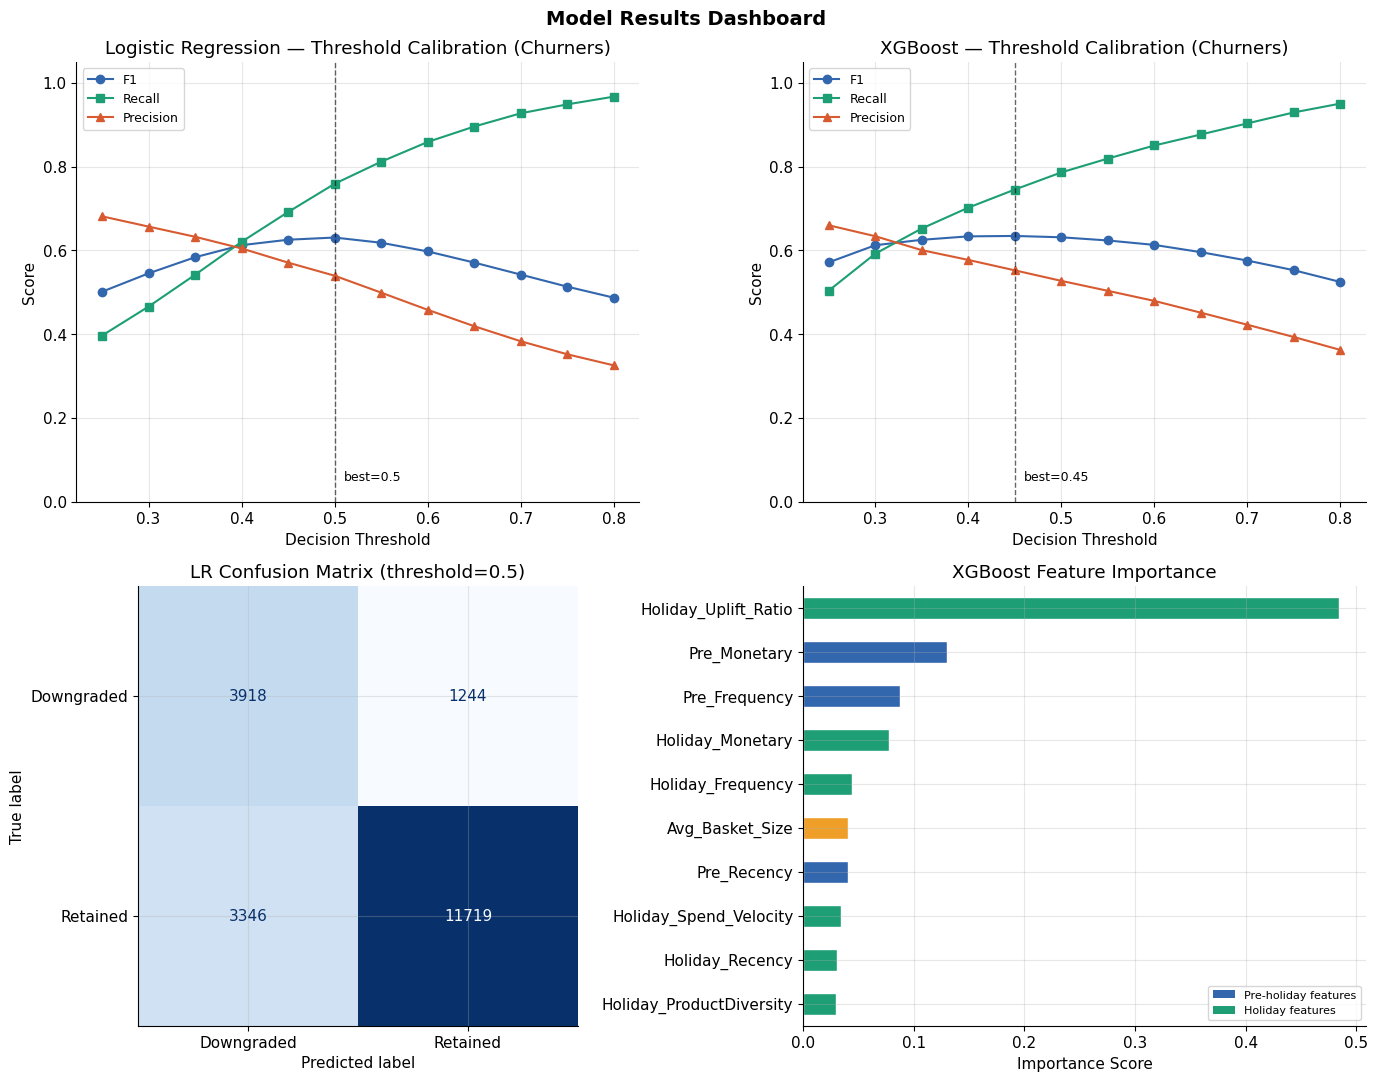

Saved: viz_05_results_dashboard.png


In [13]:
# ============================================================
# CELL 13 — VISUALISATION 4: Results Dashboard
# Threshold calibration + Confusion matrices + Feature importance
# ============================================================

# --- A. Threshold calibration for BOTH models ---
def calibrate_threshold(model, X, y_true, pos_label=0):
    """Test thresholds 0.25–0.80 and return dataframe of F1/Recall/Precision."""
    probs  = model.predict_proba(X)[:, 1]  # P(retained)
    thresholds = np.arange(0.25, 0.82, 0.05)
    rows = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        rows.append({
            'Threshold': round(t, 2),
            'F1':        round(f1_score(y_true, preds, pos_label=pos_label, zero_division=0), 4),
            'Recall':    round(recall_score(y_true, preds, pos_label=pos_label, zero_division=0), 4),
            'Precision': round(precision_score(y_true, preds, pos_label=pos_label, zero_division=0), 4),
        })
    df = pd.DataFrame(rows)
    best_t = df.loc[df['F1'].idxmax(), 'Threshold']
    return df, best_t, model.predict_proba(X)[:, 1]

lr_thresh_df,  lr_best_t,  lr_probs  = calibrate_threshold(best_lr,  X_test, y_test)
xgb_thresh_df, xgb_best_t, xgb_probs = calibrate_threshold(best_xgb, X_test, y_test)

print(f'LR  best threshold: {lr_best_t}   XGB best threshold: {xgb_best_t}')
print('\nLR Threshold Table:')
print(lr_thresh_df.to_string(index=False))
print('\nXGB Threshold Table:')
print(xgb_thresh_df.to_string(index=False))

# Apply best thresholds
y_pred_lr_opt  = (lr_probs  >= lr_best_t ).astype(int)
y_pred_xgb_opt = (xgb_probs >= xgb_best_t).astype(int)

# --- B. Build the 4-panel results dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Model Results Dashboard', fontsize=14, fontweight='bold')

# Panel 1: Threshold curves — LR
ax = axes[0, 0]
ax.plot(lr_thresh_df['Threshold'], lr_thresh_df['F1'],        marker='o', label='F1',        color='#3266ad')
ax.plot(lr_thresh_df['Threshold'], lr_thresh_df['Recall'],    marker='s', label='Recall',    color='#1D9E75')
ax.plot(lr_thresh_df['Threshold'], lr_thresh_df['Precision'], marker='^', label='Precision', color='#D85A30')
ax.axvline(lr_best_t, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.text(lr_best_t + 0.01, 0.05, f'best={lr_best_t}', fontsize=9)
ax.set_title('Logistic Regression — Threshold Calibration (Churners)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

# Panel 2: Threshold curves — XGB
ax = axes[0, 1]
ax.plot(xgb_thresh_df['Threshold'], xgb_thresh_df['F1'],        marker='o', label='F1',        color='#3266ad')
ax.plot(xgb_thresh_df['Threshold'], xgb_thresh_df['Recall'],    marker='s', label='Recall',    color='#1D9E75')
ax.plot(xgb_thresh_df['Threshold'], xgb_thresh_df['Precision'], marker='^', label='Precision', color='#D85A30')
ax.axvline(xgb_best_t, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.text(xgb_best_t + 0.01, 0.05, f'best={xgb_best_t}', fontsize=9)
ax.set_title('XGBoost — Threshold Calibration (Churners)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)

# Panel 3: Confusion matrix — LR (optimised threshold)
ax = axes[1, 0]
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr_opt,
    display_labels=['Downgraded', 'Retained'],
    cmap='Blues', ax=ax, colorbar=False
)
ax.set_title(f'LR Confusion Matrix (threshold={lr_best_t})')

# Panel 4: XGBoost feature importance
ax = axes[1, 1]
xgb_imp = pd.Series(
    best_xgb.feature_importances_, index=FEATURES
).sort_values(ascending=True)
bar_colors = ['#3266ad' if 'Pre_' in f else
              '#1D9E75' if 'Holiday_' in f else '#EF9F27'
              for f in xgb_imp.index]
xgb_imp.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance Score')

# Legend for feature colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#3266ad', label='Pre-holiday features'),
    Patch(facecolor='#1D9E75', label='Holiday features'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('viz_05_results_dashboard.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_05_results_dashboard.png')

In [16]:
# ============================================================
# CELL 14 — FINAL MODEL SELECTION + EXPORT
# ============================================================
print('Selecting the best model based on churn F1 (class 0)...')

lr_churn_f1  = f1_score(y_test, y_pred_lr_opt,  pos_label=0)
xgb_churn_f1 = f1_score(y_test, y_pred_xgb_opt, pos_label=0)

lr_recall    = recall_score(y_test, y_pred_lr_opt,  pos_label=0)
xgb_recall   = recall_score(y_test, y_pred_xgb_opt, pos_label=0)

print('\n' + '='*60)
print('HEAD-TO-HEAD COMPARISON (Churner / Class 0 metrics)')
print('='*60)
print(f"{'Model':<25} {'Churn F1':>10} {'Churn Recall':>14} {'Threshold':>12}")
print('-'*60)
print(f"{'Logistic Regression':<25} {lr_churn_f1:>10.4f} {lr_recall:>14.4f} {lr_best_t:>12.2f}")
print(f"{'XGBoost (tuned)':<25} {xgb_churn_f1:>10.4f} {xgb_recall:>14.4f} {xgb_best_t:>12.2f}")
print('='*60)

# Pick the winner automatically
if xgb_churn_f1 >= lr_churn_f1:
    winner_model  = best_xgb
    winner_name   = 'XGBoost'
    winner_thresh = xgb_best_t
    winner_probs  = xgb_probs
    winner_preds  = y_pred_xgb_opt
else:
    winner_model  = best_lr
    winner_name   = 'Logistic Regression'
    winner_thresh = lr_best_t
    winner_probs  = lr_probs
    winner_preds  = y_pred_lr_opt

print(f'\nWINNER: {winner_name}')

print('\n--- FINAL CLASSIFICATION REPORT ---')
print(classification_report(
    y_test, winner_preds,
    target_names=['Downgraded (0)', 'Retained (1)']
))

print('='*60)
print('SAVING OUTPUTS...')

# 1. Save model
joblib.dump(winner_model, 'vip_churn_best_model.pkl')
print('   -> vip_churn_best_model.pkl')

# 2. Generate at-risk hit list
# Use winner probs on ALL VIPs (train + test together)
X_all         = vip_data[FEATURES]
all_probs     = winner_model.predict_proba(X_all)[:, 1]
# Churn probability = 1 - P(retained)
churn_probs   = 1 - all_probs

vip_data['Churn_Risk_Probability'] = churn_probs
at_risk = (
    vip_data[vip_data['Churn_Risk_Probability'] >= 0.50]
    [['Churn_Risk_Probability', 'Holiday_Monetary', 'Pre_Monetary',
      'Holiday_Frequency', 'Holiday_Uplift_Ratio']]
    .sort_values(by=['Churn_Risk_Probability', 'Holiday_Monetary'],
                 ascending=[False, False])
)

at_risk.to_csv('At_Risk_VIPs_Final.csv')
print('   -> At_Risk_VIPs_Final.csv')
print(f'\n   VIPs flagged for retention : {len(at_risk):,}')
print(f'   Avg holiday spend flagged  : £{at_risk["Holiday_Monetary"].mean():,.2f}')
print('='*60)

display(at_risk.head(10))

Selecting the best model based on churn F1 (class 0)...

HEAD-TO-HEAD COMPARISON (Churner / Class 0 metrics)
Model                       Churn F1   Churn Recall    Threshold
------------------------------------------------------------
Logistic Regression           0.6306         0.7590         0.50
XGBoost (tuned)               0.6344         0.7451         0.45

WINNER: XGBoost

--- FINAL CLASSIFICATION REPORT ---
                precision    recall  f1-score   support

Downgraded (0)       0.55      0.75      0.63      5162
  Retained (1)       0.90      0.79      0.84     15065

      accuracy                           0.78     20227
     macro avg       0.73      0.77      0.74     20227
  weighted avg       0.81      0.78      0.79     20227

SAVING OUTPUTS...
   -> vip_churn_best_model.pkl
   -> At_Risk_VIPs_Final.csv

   VIPs flagged for retention : 30,685
   Avg holiday spend flagged  : £248.41


,Churn_Risk_Probability,Holiday_Monetary,Pre_Monetary,Holiday_Frequency,Holiday_Uplift_Ratio
CUST_CODE,,,,,
CUST0000955587,0.972745,242.19,178.20,4,8.154545
CUST0000423085,0.965833,167.87,270.06,2,3.729616
CUST0000508654,0.965613,250.77,270.06,4,5.571429
CUST0000973582,0.965159,593.10,358.27,13,9.932732
CUST0000027849,0.963159,288.92,276.94,3,6.259551
CUST0000888182,0.963113,236.39,148.33,4,9.562058
CUST0000299333,0.961998,264.85,230.85,4,6.883691
CUST0000461062,0.961885,502.01,568.67,11,5.296675
CUST0000300785,0.961855,203.76,453.33,4,2.696843
